In [291]:
import string
import itertools
import numpy as np
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import gridspec
from matplotlib.colors import LogNorm

import seaborn as sns
sns.set(style="ticks", color_codes=True, font_scale=1.2, rc={"xtick.bottom" : True, "ytick.left" : True})
sns.set_style({"xtick.direction": "in", "ytick.direction": "in"})

In [293]:
import mdtraj as md

# Analysis of interactions

In [294]:
def unit_normal_vector(v1, v2):
    """Calculates the unit normal vector to a plane defined by two vectors.

    Args:
        v1: The first vector defining the plane.
        v2: The second vector defining the plane.

    Returns:
        The unit normal vector to the plane.
    """

    normal = np.cross(v1, v2, axisa=1)
    norm = np.linalg.norm(normal, axis=1).reshape(np.shape(normal)[0],1)
    normal = normal / norm
    return normal

In [295]:
def get_normal(coords, id, sidechain_atoms):
    """
    Calculate the normal vector to the plane defined by three atoms

    Parameters
    ----------
        coords: 
            The coordinates of the atoms
    Returns
    -------
        normal: 
            The normal vector to the plane defined by the three atoms

    """
    try: 
        i, j, k = [x.index for x in coords.topology.residue(id).atoms if x.name in sidechain_atoms]
        displacements = md.compute_displacements(coords, [[i,j], [i,k]])
        normal = unit_normal_vector(displacements[:,0,:], displacements[:,1,:])
        return normal
    except ValueError as e:
        return None

In [296]:
culled = "cullpdb_pc15.0_res0.0-1.5_len40-10000_R0.25_Xray_d2025_02_19_chains1916.txt"
with open(culled, 'r') as f:
    raw = f.readlines()
pdbids = [r.split()[0] for r in raw][1:]
print(pdbids)

['5D8VA', '3NIRA', '5NW3A', '1UCSA', '3X2MA', '2VB1A', '1US0A', '6E6OA', '6S2MA', '1R6JA', '4REKA', '4I8HA', '2WFIA', '2OV0A', '2B97A', '8C5NA', '3X34A', '7KR0A', '6L27A', '5YCEA', '1GCIA', '7A5MA', '5GV8A', '6ZM8A', '1X6ZA', '4UA6A', '5TDAA', '7AF2AAA', '3UI4A', '5AL6A', '5NFMA', '1W0NA', '5HB7A', '2VXNA', '1NWZA', '8C3XA', '7AVKA', '2JFRA', '2O9SA', '4Y9WA', '6TGUA', '1P9GA', '7BNHA', '2O7AA', '2YKZA', '4EICA', '6EIOA', '4PSSA', '4AYOA', '6Q00A', '6Q00B', '3O4PA', '6ETLA', '1MC2A', '1X8QA', '7BBXA', '7AOTA', '3QPAA', '2FMAA', '5XVTA', '2F01A', '1G6XA', '3WDNA', '1MUWA', '3ZSJA', '6ZPAA', '2DDXA', '1V6PA', '8EREA', '4HS1A', '5L87A', '1GWEA', '3ZOJA', '3FILA', '4F1VA', '5LP9A', '1I1WA', '4U9HL', '4U9HS', '6KFNA', '8JZ8A', '7TVLA', '4O6UA', '4UYRA', '3IP0A', '8PB5A', '8AVUA', '4WEEA', '4Y9VA', '1IX9A', '6KLZA', '7OUZA', '6FMCA', '4NPDA', '1VYRA', '8VOLA', '7PSYA', '3VORA', '3G21A', '5GJIA', '3ZR8X', '4EA9A', '2XU3A', '6LK1A', '1J0PA', '5IG6A', '5BR4A', '3X0IA', '8CR4A', '5MK9A', '4HNOA'

In [297]:
pdb_coords = {}
res_names = ['PHE', 'TYR', 'ARG', 'LYS']
# Loop over all PDB files
for prot in pdbids:
    try:
        # Load the PDB file
        pdb_file = md.load_pdb("PDB/pdb%s.ent"%prot.lower()[:4])
    except FileNotFoundError as e:
        print ("File %s not found" % (prot[:4]))
        #print (e)
        continue

    # Select the chain ID from the PDB file
    try:
        chainid = string.ascii_uppercase.index(prot[4])
    except ValueError as e:
        print (e)
        print (prot)
        continue

    try:
        sel = pdb_file.top.select('chainid %i'%chainid)
        pdb_file = pdb_file.atom_slice(sel)
    except IndexError as e:
        print ("Chain %s not found in %s" % (prot[4], prot[:4]))
        continue

    # Select residues
    try:
        sel = []
        for name in res_names:
            sel += list(pdb_file.top.select('resname %s and symbol != H'%name))
        sel = sorted(sel)
    except Exception as e:
        print (e)
        break
    pdb_coords[prot] = pdb_file[0].atom_slice((sel)) #np.concatenate(sel) #pdb_file[0].atom_slice(sel)

File 7AF2 not found
Chain L not found in 4U9H
Chain S not found in 4U9H
File 8VOL not found
Chain X not found in 3ZR8
File 7P24 not found
Chain X not found in 4Q4G
File 6TN1 not found
Chain X not found in 2CE2
Chain X not found in 6UKF
Chain X not found in 2QCP
Chain X not found in 4UDX
Chain P not found in 6TVE
File 8OHT not found
Chain X not found in 1PMH
File 7ZUG not found
File 9GIR not found
Chain X not found in 3WA2
File 6XY7 not found
File 7NQG not found
Chain O not found in 2I5V
File 8OVS not found
File 9DA2 not found
Chain X not found in 2ZK9
File 6TWP not found
Chain M not found in 8OV5
Chain X not found in 2ZPT
Chain X not found in 2O9U
Chain M not found in 1E4M
File 7QYM not found
File 7QYM not found
File 8PAE not found
File 7VUB not found
File 7AVC not found
File 7ZIL not found
File 7PJ4 not found
Chain L not found in 6R2W
File 9MDC not found
File 6TAK not found
File 9F96 not found
File 7Q4T not found
Chain X not found in 5N8A
File 7OMV not found
File 7OS5 not found
Chain 

In [298]:
contacts = {}
aro_sidechain = ['CG', 'CD1', 'CD2', 'CE1', 'CE2', 'CZ']
charged_sidechain = ['NZ', 'NE', 'NH1', 'NH2']

pdb_ids = []
resSeqs_i = []; resSeqs_j = []
codes_i = []; codes_j = []
dmins = []; dvecs = []
thetas = []; theta1s = []; theta2s = []; ttheta1s = []; ttheta2s = [] 

for pdb, coords in pdb_coords.items(): # Loop over PDB files
    print (pdb)
    print (coords.top)
    #print ([coords.topology.residue(i).code for i in range(coords.topology.n_residues)])
    res_pairs = list(itertools.combinations(range(coords.topology.n_residues), 2))
    try:
        dist, pairs = md.compute_contacts(coords, res_pairs, periodic=False, scheme='sidechain-heavy')
    except ValueError as e:
        print (e)
        continue
    #print (list(zip(dist[0], pairs)))
    for k, d in enumerate(dist.ravel()):
        if d < 0.45:
            i, j = pairs[k][0], pairs[k][1]
            ires, jres = coords.topology.residue(i), coords.topology.residue(j)
            iseq,  jseq = coords.topology.residue(i).resSeq, coords.topology.residue(j).resSeq
            ic, jc = coords.topology.residue(i).code, coords.topology.residue(j).code

            ii, ji = coords.topology.residue(i).resSeq, coords.topology.residue(j).resSeq
            id, jd = coords.topology.residue(i).code, coords.topology.residue(j).code

            # Compute vector between sidechains
            if ic in ['F', 'Y']:
                isel = [x.index for x in coords.topology.residue(i).atoms if \
                               x.name in aro_sidechain]
            elif ic in ['R', 'K']:    
                isel = [x.index for x in coords.topology.residue(i).atoms if \
                               x.name in charged_sidechain]
            if jc in ['F', 'Y']:
                jsel = [x.index for x in coords.topology.residue(j).atoms if \
                               x.name in aro_sidechain]
            elif jc in ['R', 'K']:    
                jsel = [x.index for x in coords.topology.residue(j).atoms if \
                               x.name in charged_sidechain]
            try:
                displacement = md.compute_displacements(coords, \
                                            list(itertools.product(isel, jsel)), periodic=False)[0]
                dvec = np.mean(displacement, axis=0)
                dvec_mod = np.linalg.norm(dvec)
                dvec_unit = dvec/dvec_mod
            except ValueError as e:
                print (e)
                print ("Not enough atoms in residue pair: ", iseq, jseq)
                dvec = None
                dvec_mod = None
                dvec_unit = None
                continue
            
            # Compute the normal vector to the plane defined by the sidechain atoms
            if id in ['F', 'Y']:
                n_i = get_normal(coords, i, aro_sidechain[:3])
            elif id in ['R']:
                n_i = get_normal(coords, i, charged_sidechain[1:])
            else:
                n_i = None

            if jd in ['F', 'Y']:
                n_j = get_normal(coords, j, aro_sidechain[:3])
            elif jd in ['R']:
                n_j = get_normal(coords, j, charged_sidechain[1:])
            else:
                n_j = None
            
            theta = None; theta1 = None; theta2 = None
            ttheta1 = None; ttheta2 = None # set angles to none by default
            try:
                theta = np.min([np.arccos((n_i*n_j).sum()), np.arccos((-n_i*n_j).sum())])
            except TypeError as e:
                theta = None

            try:
                if id in ['F']:
                    if jd in ['F', 'Y']:
                        ttheta1 = np.pi/2 - np.min([np.arccos((n_i*dvec_unit).sum()), \
                                                    np.arccos((-n_i*dvec_unit).sum())])
                        ttheta2 = np.pi/2 - np.min([np.arccos((n_j*dvec_unit).sum()), \
                                                    np.arccos((-n_j*dvec_unit).sum())])
                    elif jd in ['K', 'R']:
                        theta1 = np.min([np.arccos((n_i*dvec_unit).sum()), \
                                         np.arccos((-n_i*dvec_unit).sum())])
                        theta2 = [np.min([np.arccos((n_j*dvec_unit).sum()), \
                                          np.arccos((-n_j*dvec_unit).sum())]) if jd in ['R'] else None][0]
                elif id in ['Y']:
                    if jd in ['F', 'Y']:
                        ttheta1 = np.pi/2 - np.min([np.arccos((n_j*dvec_unit).sum()), \
                                                    np.arccos((-n_j*dvec_unit).sum())])
                        ttheta2 = np.pi/2 - np.min([np.arccos((n_i*dvec_unit).sum()), \
                                                    np.arccos((-n_i*dvec_unit).sum())])
                    elif jd in ['K', 'R']:
                        theta1 = np.min([np.arccos((n_i*dvec_unit).sum()), \
                                         np.arccos((-n_i*dvec_unit).sum())])
                        theta2 = [np.min([np.arccos((n_j*dvec_unit).sum()), \
                                          np.arccos((-n_j*dvec_unit).sum())]) if jd in ['R'] else None][0]
                elif id in ['K', 'R']:
                    if jd in ['F', 'Y']:
                        theta1 = np.min([np.arccos((n_j*dvec_unit).sum()), \
                                         np.arccos((-n_j*dvec_unit).sum())])
                        theta2 = [np.min([np.arccos((n_i*dvec_unit).sum()), \
                                          np.arccos((-n_i*dvec_unit).sum())]) if id in ['R'] else None][0]
                    else:
                        theta1 = [np.min([np.arccos((n_i*dvec_unit).sum()), \
                                          np.arccos((-n_i*dvec_unit).sum())]) if id in ['R'] else None][0]
                        theta2 = [np.min([np.arccos((n_j*dvec_unit).sum()), \
                                          np.arccos((-n_j*dvec_unit).sum())]) if jd in ['R'] else None][0]
 
            except TypeError as e:
                print (e)

            pdb_ids.append(pdb)
            codes_i.append(ic); codes_j.append(jc)
            resSeqs_i.append(ires); resSeqs_j.append(jres)
            
            dmins.append(d)
            dvecs.append(dvec_mod)

            thetas.append(theta)
            theta1s.append(theta1); theta2s.append(theta2)
            ttheta1s.append(ttheta1); ttheta2s.append(ttheta2)
            
contacts_df = pd.DataFrame({'pdb': pdb_ids, 'res_i': codes_i, 'res_j': codes_j, 'resSeq_i': resSeqs_i, \
                            'resSeq_j': resSeqs_j, 'dmin': dmins, 'dvec' : dvecs, 'theta': thetas, \
                            'theta1': theta1s, 'theta2': theta2s, 'ttheta1': ttheta1s, 'ttheta2': ttheta2s})

5D8VA
<mdtraj.Topology with 1 chains, 10 residues, 101 atoms, 95 bonds>
3NIRA
<mdtraj.Topology with 1 chains, 5 residues, 57 atoms, 55 bonds>
5NW3A
<mdtraj.Topology with 1 chains, 9 residues, 192 atoms, 87 bonds>
1UCSA
<mdtraj.Topology with 1 chains, 6 residues, 59 atoms, 54 bonds>
3X2MA
<mdtraj.Topology with 1 chains, 20 residues, 216 atoms, 213 bonds>
2VB1A
<mdtraj.Topology with 1 chains, 23 residues, 244 atoms, 231 bonds>
1US0A
<mdtraj.Topology with 1 chains, 57 residues, 588 atoms, 560 bonds>
6E6OA
<mdtraj.Topology with 1 chains, 5 residues, 59 atoms, 58 bonds>
6S2MA
<mdtraj.Topology with 1 chains, 32 residues, 705 atoms, 301 bonds>
1R6JA
<mdtraj.Topology with 1 chains, 10 residues, 101 atoms, 95 bonds>
4REKA
<mdtraj.Topology with 1 chains, 90 residues, 967 atoms, 929 bonds>
4I8HA
<mdtraj.Topology with 1 chains, 29 residues, 301 atoms, 286 bonds>
2WFIA
<mdtraj.Topology with 1 chains, 39 residues, 407 atoms, 391 bonds>
2OV0A
<mdtraj.Topology with 1 chains, 18 residues, 186 atoms, 17

In [299]:
contacts_df

,pdb,res_i,res_j,resSeq_i,resSeq_j,dmin,dvec,theta,theta1,theta2,ttheta1,ttheta2
0,5D8VA,Y,F,TYR19,PHE64,0.448051,0.590764,0.913655,NaN,NaN,1.067686,1.1534
1,5D8VA,F,K,PHE64,LYS67,0.422619,0.794475,NaN,1.442892,NaN,NaN,NaN
2,3NIRA,R,F,ARG10,PHE13,0.433863,0.585247,1.233658,0.517593,0.875230,NaN,NaN
3,3NIRA,F,R,PHE13,ARG17,0.362366,0.657059,0.793855,0.978311,1.031952,NaN,NaN
4,5NW3A,K,F,LYS6,PHE48,0.310219,0.940045,NaN,0.882583,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
32188,2IT2A,R,R,ARG104,ARG152,0.332336,0.397486,1.072557,0.349956,0.932339,NaN,NaN
32189,2IT2A,F,K,PHE130,LYS187,0.370562,0.648984,NaN,0.183362,NaN,NaN,NaN
32190,2IT2A,Y,R,TYR132,ARG148,0.327819,0.461523,1.180847,0.635105,0.722974,NaN,NaN
32191,2IT2A,K,R,LYS187,ARG190,0.339773,0.684704,NaN,NaN,1.450844,NaN,NaN


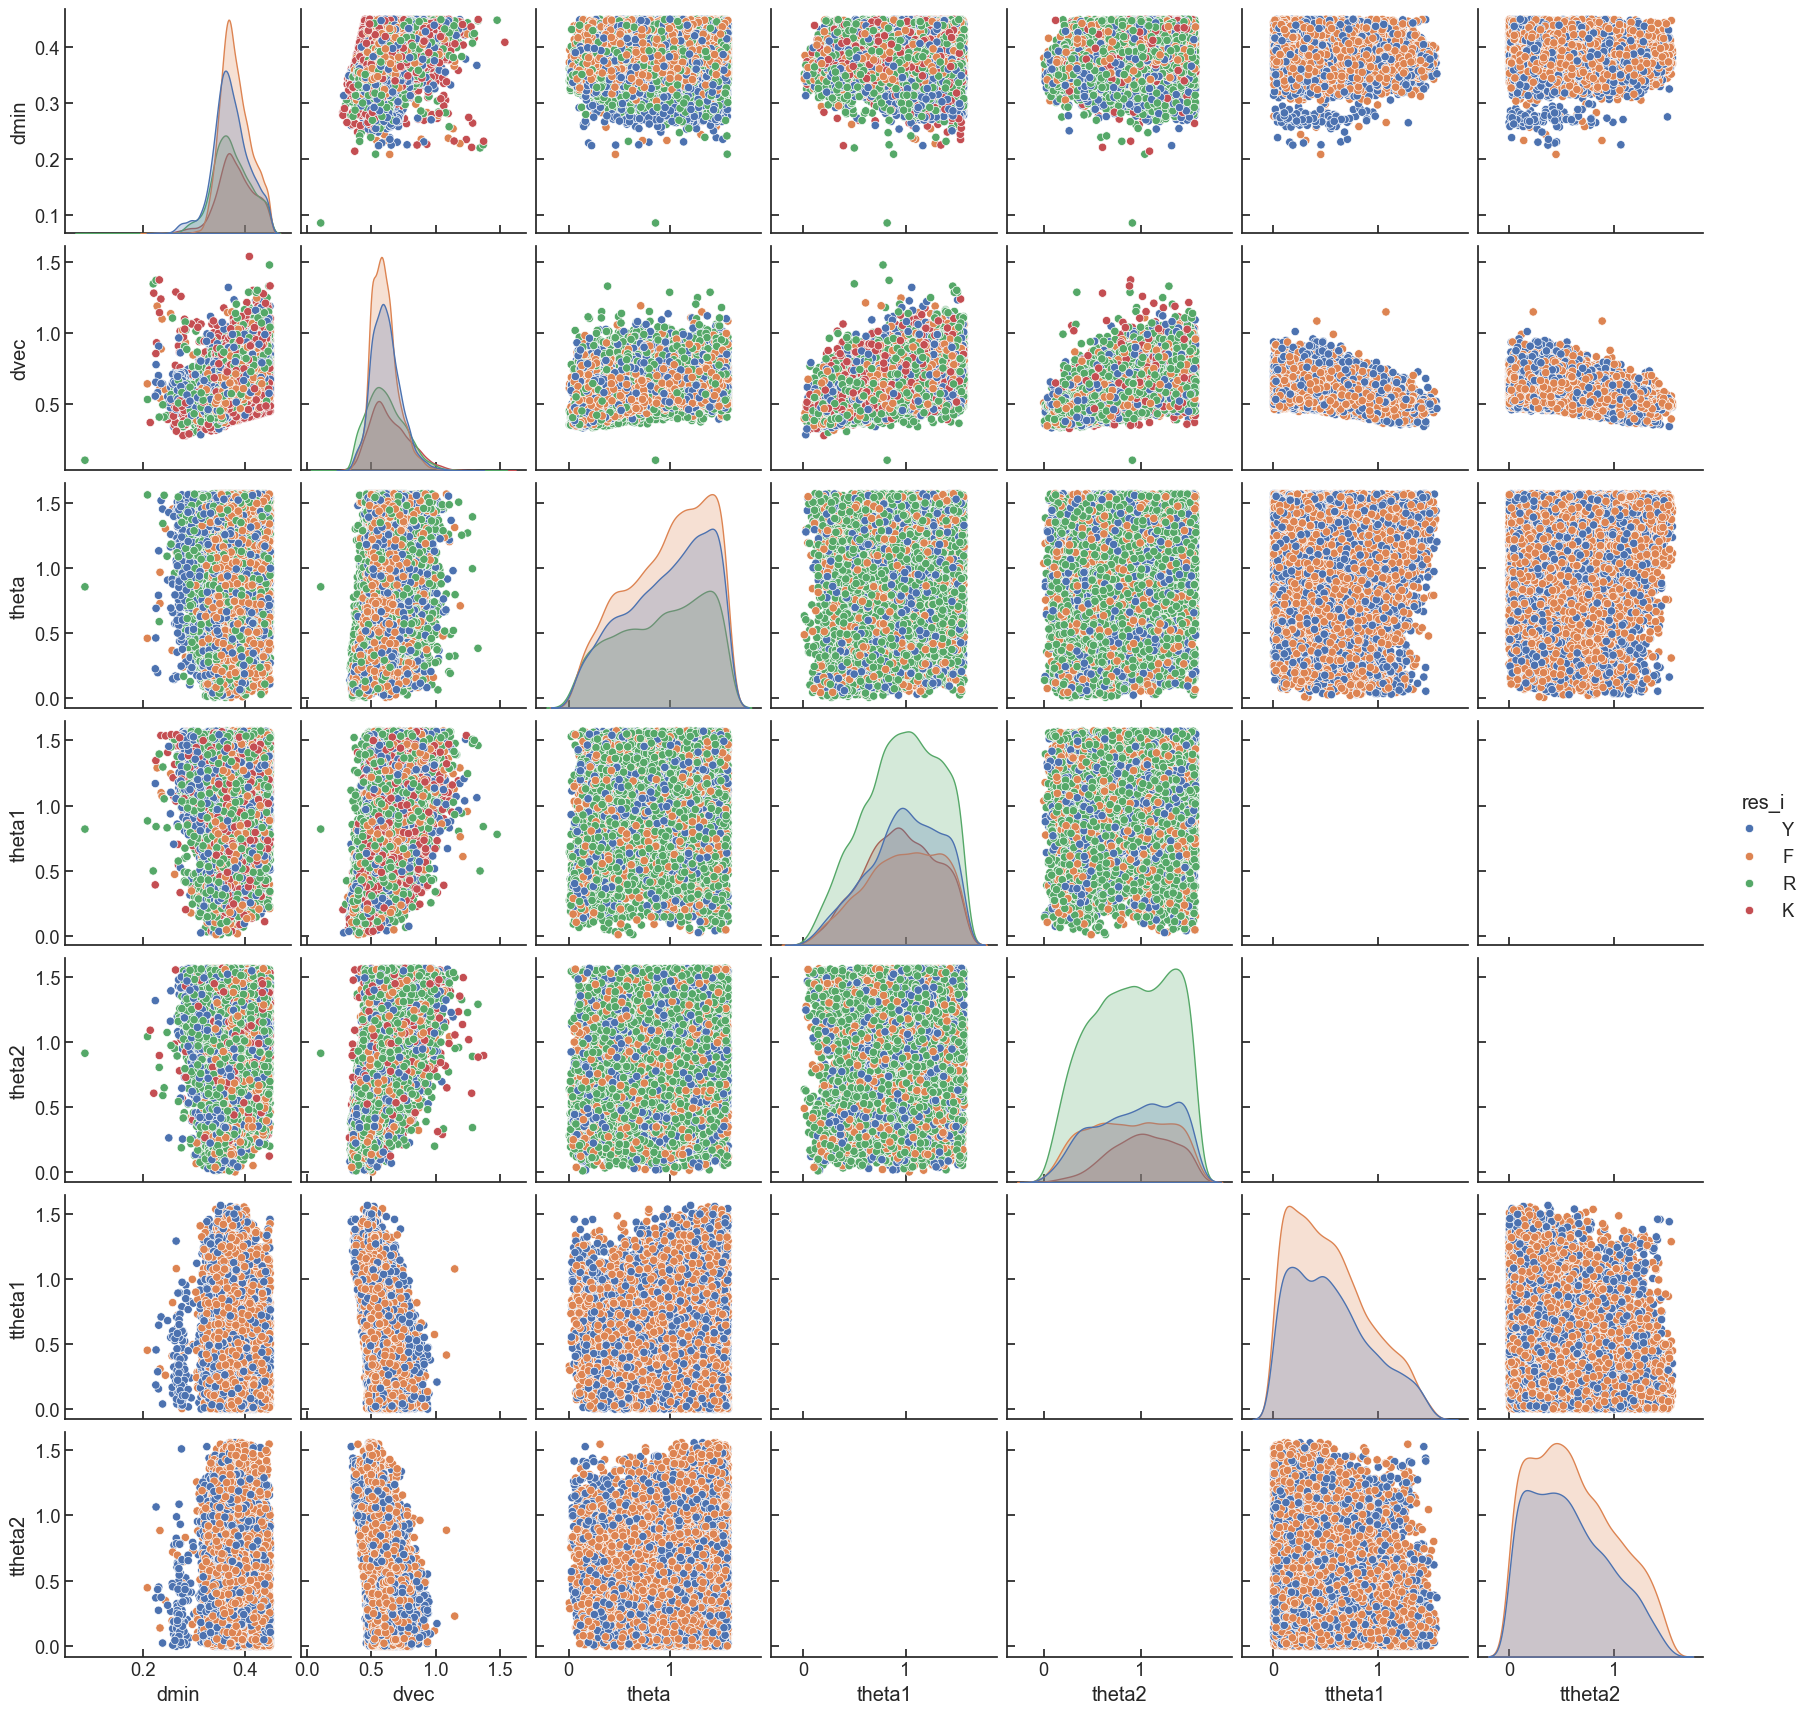

In [300]:
sns.pairplot(contacts_df, hue="res_i")

In [301]:
contacts_df[contacts_df['pdb']=='2VB1A']

,pdb,res_i,res_j,resSeq_i,resSeq_j,dmin,dvec,theta,theta1,theta2,ttheta1,ttheta2
26,2VB1A,K,F,LYS1,PHE3,0.360903,0.487941,NaN,0.204604,NaN,NaN,NaN
27,2VB1A,F,F,PHE3,PHE38,0.399754,0.785095,1.298365,NaN,NaN,0.418395,0.837488
28,2VB1A,R,F,ARG5,PHE38,0.376486,0.911797,0.669213,1.164317,1.514359,NaN,NaN
29,2VB1A,Y,R,TYR20,ARG21,0.346485,0.477257,0.461955,0.697546,0.646792,NaN,NaN
30,2VB1A,Y,K,TYR20,LYS96,0.355632,0.552637,NaN,0.747607,NaN,NaN,NaN
31,2VB1A,K,F,LYS33,PHE34,0.372143,0.627034,NaN,0.522239,NaN,NaN,NaN
32,2VB1A,K,F,LYS33,PHE38,0.370754,0.586288,NaN,0.676368,NaN,NaN,NaN
33,2VB1A,F,R,PHE34,ARG114,0.337095,0.446827,0.278782,0.753982,0.615590,NaN,NaN
34,2VB1A,Y,R,TYR53,ARG68,0.319916,0.697329,1.028186,1.468951,1.175047,NaN,NaN
35,2VB1A,R,K,ARG112,LYS116,0.412499,0.620277,NaN,1.476036,NaN,NaN,NaN


In [302]:
contacts_df[contacts_df['pdb']=='3BHWA']

,pdb,res_i,res_j,resSeq_i,resSeq_j,dmin,dvec,theta,theta1,theta2,ttheta1,ttheta2
32162,3BHWA,R,Y,ARG5,TYR6,0.317819,0.527665,1.541958,0.692283,1.166831,NaN,NaN
32163,3BHWA,Y,Y,TYR6,TYR126,0.371285,0.635627,1.263403,NaN,NaN,0.717219,1.121527
32164,3BHWA,Y,R,TYR6,ARG133,0.292062,0.520903,0.949958,1.122871,1.401330,NaN,NaN
32165,3BHWA,R,K,ARG37,LYS55,0.326943,0.452338,NaN,1.388253,NaN,NaN,NaN
32166,3BHWA,F,Y,PHE89,TYR161,0.375466,0.611197,1.036676,NaN,NaN,0.446341,0.105161
32167,3BHWA,F,Y,PHE102,TYR126,0.362033,0.506361,0.865864,NaN,NaN,0.339804,1.141689
32168,3BHWA,F,Y,PHE102,TYR153,0.433232,0.642777,0.992409,NaN,NaN,0.353213,0.949001
32169,3BHWA,R,R,ARG108,ARG193,0.358147,0.557708,1.101312,0.591800,0.528755,NaN,NaN
32170,3BHWA,F,Y,PHE111,TYR161,0.382714,0.605640,1.046317,NaN,NaN,0.414296,0.154532
32171,3BHWA,F,R,PHE114,ARG115,0.342177,0.505434,1.218531,0.875390,1.102851,NaN,NaN


In [303]:
contactsFF = (contacts_df.res_i == 'F') & (contacts_df.res_j == 'F')
contacts_df[contactsFF]

,pdb,res_i,res_j,resSeq_i,resSeq_j,dmin,dvec,theta,theta1,theta2,ttheta1,ttheta2
12,5NW3A,F,F,PHE29,PHE48,0.233092,0.540930,0.727976,NaN,NaN,0.297659,0.884339
14,3X2MA,F,F,PHE15,PHE113,0.385611,0.623890,0.448674,NaN,NaN,0.355852,0.516249
15,3X2MA,F,F,PHE15,PHE125,0.355004,0.475236,1.058035,NaN,NaN,1.281847,0.487745
16,3X2MA,F,F,PHE15,PHE126,0.378771,0.719452,1.195846,NaN,NaN,0.525513,0.670109
19,3X2MA,F,F,PHE58,PHE113,0.388324,0.537745,1.033714,NaN,NaN,1.141026,0.154088
...,...,...,...,...,...,...,...,...,...,...,...,...
32155,4W8PA,F,F,PHE1525,PHE1575,0.357585,0.470576,1.162444,NaN,NaN,1.421267,0.279507
32156,4W8PA,F,F,PHE1525,PHE1581,0.385099,0.528606,0.880017,NaN,NaN,0.339371,1.118763
32159,4W8PA,F,F,PHE1575,PHE1581,0.360112,0.516939,1.114465,NaN,NaN,1.077016,0.250761
32180,1ZHVA,F,F,PHE68,PHE72,0.361998,0.692362,1.073172,NaN,NaN,0.188074,0.598725


In [316]:
#sel = (contacts_df.res_i == 'F') & (contacts_df.res_j == 'F')
#sel = (contacts_df.res_i == 'Y') & (contacts_df.res_j == 'Y')
#sel = (contacts_df.res_i == 'R') & (contacts_df.res_j == 'Y')
#sel = pd.DataFrame([(contacts_df.res_i == 'F') & (contacts_df.res_j == 'Y'), \
#                    (contacts_df.res_i == 'Y') & (contacts_df.res_j == 'F')]).any()
sel = pd.DataFrame([(contacts_df.res_i == 'Y') & (contacts_df.res_j == 'R'), \
                    (contacts_df.res_i == 'R') & (contacts_df.res_j == 'Y')]).any()
contacts_df[sel]

,pdb,res_i,res_j,resSeq_i,resSeq_j,dmin,dvec,theta,theta1,theta2,ttheta1,ttheta2
29,2VB1A,Y,R,TYR20,ARG21,0.346485,0.477257,0.461955,0.697546,0.646792,NaN,NaN
34,2VB1A,Y,R,TYR53,ARG68,0.319916,0.697329,1.028186,1.468951,1.175047,NaN,NaN
41,1US0A,R,Y,ARG69,TYR103,0.331811,0.394170,0.177689,0.540974,0.468327,NaN,NaN
47,1US0A,Y,R,TYR189,ARG232,0.403743,0.662861,0.675075,1.364100,1.362535,NaN,NaN
49,1US0A,Y,R,TYR189,ARG293,0.379315,0.617137,0.943098,0.258059,1.060859,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
32164,3BHWA,Y,R,TYR6,ARG133,0.292062,0.520903,0.949958,1.122871,1.401330,NaN,NaN
32173,3BHWA,R,Y,ARG120,TYR153,0.351218,0.451652,0.130757,0.560728,0.648436,NaN,NaN
32174,3BHWA,R,Y,ARG120,TYR168,0.314083,0.578940,1.067368,1.012969,1.563916,NaN,NaN
32175,3BHWA,Y,R,TYR126,ARG133,0.365950,0.573860,0.938577,0.883296,1.524345,NaN,NaN


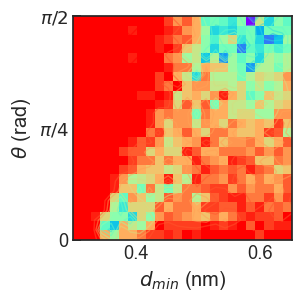

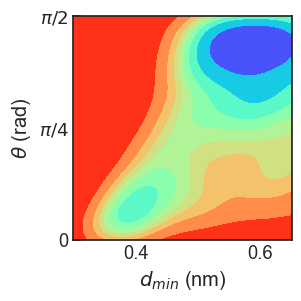

In [317]:
nbins = 25 

xmin = 0.3; xmax = 0.65
ymin = 0; ymax = np.pi/2

fig, ax = plt.subplots(figsize=(3.25, 3.25))
counts, xbins, ybins, image = ax.hist2d(contacts_df[sel].dvec, contacts_df[sel].theta, \
                                bins=(np.linspace(xmin, xmax, nbins), np.linspace(ymin, ymax, nbins)), \
                                cmap='rainbow_r', density=True)
vmin = 0; vmax = np.max(counts)
cs = ax.contour(counts.T, extent=[xbins.min(),xbins.max(),ybins.min(),ybins.max()], \
           linewidths=1, cmap='rainbow_r', alpha=0.5, levels=np.linspace(vmin, vmax, 10))
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_yticks([0, np.pi/4, np.pi/2])
ax.set_yticklabels(['0', r'$\pi/4$', r'$\pi/2$'])
ax.set_xlabel('$d_{min}$ (nm)')
ax.set_ylabel(r'$\theta$ (rad)')
#plt.colorbar(image)
plt.tight_layout()


fig, ax = plt.subplots(figsize=(3.25, 3.25))
sns.kdeplot(data=contacts_df[sel], x='dvec', y='theta', ax=ax, cmap='rainbow_r', fill=True, thresh=0, levels=10)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_yticks([0, np.pi/4, np.pi/2])
ax.set_yticklabels(['0', r'$\pi/4$', r'$\pi/2$'])
ax.set_xlabel('$d_{min}$ (nm)')
ax.set_ylabel(r'$\theta$ (rad)')
plt.tight_layout()

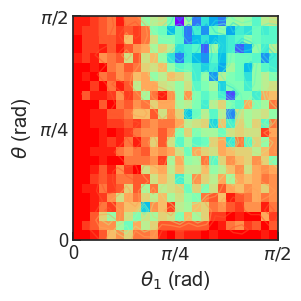

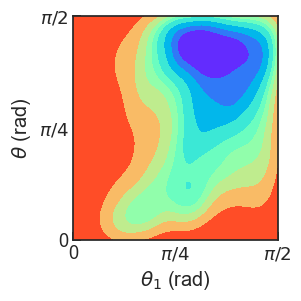

In [318]:
nbins = 25 

xmin = 0; xmax = np.pi/2
ymin = 0; ymax = np.pi/2

fig, ax = plt.subplots(figsize=(3.25, 3.25))
counts, xbins, ybins, image = ax.hist2d(contacts_df[sel].theta1, contacts_df[sel].theta, \
                                bins=(np.linspace(xmin, xmax, nbins), np.linspace(ymin, ymax, nbins)), \
                                cmap='rainbow_r')

vmin = 0; vmax = np.max(counts)
cs = ax.contour(counts.T, extent=[xbins.min(),xbins.max(),ybins.min(),ybins.max()], \
           linewidths=1, cmap='rainbow_r', alpha=0.5, levels=np.linspace(vmin, vmax, 10))
ax.set_xlim(0., np.pi/2)
ax.set_ylim(0., np.pi/2)
ax.set_xticks([0, np.pi/4, np.pi/2])
ax.set_yticks([0, np.pi/4, np.pi/2])
ax.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$'])
ax.set_yticklabels(['0', r'$\pi/4$', r'$\pi/2$'])
ax.set_xlabel(r'$\theta_1$ (rad)')
ax.set_ylabel(r'$\theta$ (rad)')
#plt.colorbar(image)
plt.tight_layout()

fig, ax = plt.subplots(figsize=(3.25, 3.25))
sns.kdeplot(data=contacts_df[sel], x='theta1', y='theta', ax=ax, cmap='rainbow_r', fill=True, thresh=0, levels=10)
ax.set_xlim(0., np.pi/2)
ax.set_ylim(0., np.pi/2)
ax.set_xticks([0, np.pi/4, np.pi/2])
ax.set_yticks([0, np.pi/4, np.pi/2])
ax.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$'])
ax.set_yticklabels(['0', r'$\pi/4$', r'$\pi/2$'])
ax.set_xlabel(r'$\theta_1$ (rad)')
ax.set_ylabel(r'$\theta$ (rad)')
plt.tight_layout()

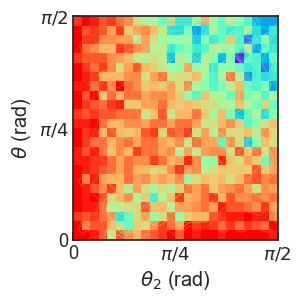

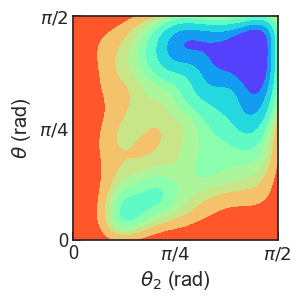

In [319]:
nbins = 25 

xmin = 0; xmax = np.pi/2
ymin = 0; ymax = np.pi/2

fig, ax = plt.subplots(figsize=(3.25, 3.25))
counts, xbins, ybins, image = ax.hist2d(contacts_df[sel].theta2, contacts_df[sel].theta, \
                                bins=(np.linspace(xmin, xmax, nbins), np.linspace(ymin, ymax, nbins)), \
                                cmap='rainbow_r')

vmin = 0; vmax = np.max(counts)
cs = ax.contour(counts.T, extent=[xbins.min(),xbins.max(),ybins.min(),ybins.max()], \
           linewidths=1, cmap='rainbow_r', alpha=0.5, levels=np.linspace(vmin, vmax, 10))
ax.set_xlim(0., np.pi/2)
ax.set_ylim(0., np.pi/2)
ax.set_xticks([0, np.pi/4, np.pi/2])
ax.set_yticks([0, np.pi/4, np.pi/2])
ax.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$'])
ax.set_yticklabels(['0', r'$\pi/4$', r'$\pi/2$'])
ax.set_xlabel(r'$\theta_2$ (rad)')
ax.set_ylabel(r'$\theta$ (rad)')
#plt.colorbar(image)
plt.tight_layout()

fig, ax = plt.subplots(figsize=(3.25, 3.25))
sns.kdeplot(data=contacts_df[sel], x='theta2', y='theta', ax=ax, cmap='rainbow_r', fill=True, thresh=0, levels=10)
ax.set_xlim(0., np.pi/2)
ax.set_ylim(0., np.pi/2)
ax.set_xticks([0, np.pi/4, np.pi/2])
ax.set_yticks([0, np.pi/4, np.pi/2])
ax.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$'])
ax.set_yticklabels(['0', r'$\pi/4$', r'$\pi/2$'])
ax.set_xlabel(r'$\theta_2$ (rad)')
ax.set_ylabel(r'$\theta$ (rad)')
plt.tight_layout()

ValueError: Contour levels must be increasing

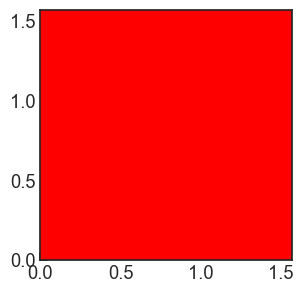

In [320]:
nbins = 25

xmin = 0; xmax = np.pi/2
ymin = 0; ymax = np.pi/2

fig, ax = plt.subplots(figsize=(3.25, 3.25))
counts, xbins, ybins, image = ax.hist2d(contacts_df[sel].theta, contacts_df[sel].ttheta2, \
                                bins=(np.linspace(xmin, xmax, nbins), np.linspace(ymin, ymax, nbins)), \
                                cmap='rainbow_r')
vmin = 0; vmax = np.max(counts)
cs = ax.contour(counts.T, extent=[xbins.min(),xbins.max(),ybins.min(),ybins.max()], \
           linewidths=1, cmap='rainbow_r', alpha=0.5, levels=np.linspace(vmin, vmax, 10))
ax.set_xlim(0., np.pi/2)
ax.set_ylim(0., np.pi/2)
ax.set_xticks([0, np.pi/4, np.pi/2])
ax.set_yticks([0, np.pi/4, np.pi/2])
ax.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$'])
ax.set_yticklabels(['0', r'$\pi/4$', r'$\pi/2$'])
ax.set_xlabel(r'$\theta$ (rad)')
ax.set_ylabel(r'$\theta_2$ (rad)')
#plt.colorbar(image)
plt.tight_layout()

fig, ax = plt.subplots(figsize=(3.25, 3.25))
sns.kdeplot(data=contacts_df[sel], x='theta', y='ttheta2', ax=ax, cmap='rainbow_r', fill=True, thresh=0, levels=10)
ax.set_xlim(0., np.pi/2)
ax.set_ylim(0., np.pi/2)
ax.set_xticks([0, np.pi/4, np.pi/2])
ax.set_yticks([0, np.pi/4, np.pi/2])
ax.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$'])
ax.set_yticklabels(['0', r'$\pi/4$', r'$\pi/2$'])
ax.set_xlabel(r'$\theta$ (rad)')
ax.set_ylabel(r'$T\theta_2$ (rad)')
plt.tight_layout()